In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

df = pd.read_csv("cookie_cats.csv")
print(df.shape)
print(df.head())
print(df["version"].value_counts())
print(df.isnull().sum())

(90189, 5)
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


In [6]:
summary = df.groupby("version")[["retention_1", "retention_7"]].mean()*100
print(summary.round(2))

         retention_1  retention_7
version                          
gate_30        44.82        19.02
gate_40        44.23        18.20


In [9]:
def ab_test(metric):
    a = df[df["version"] == "gate_30"][metric]
    b = df[df["version"] == "gate_40"][metric]
    successes = [int(a.sum()), int(b.sum())]
    num_of_obs = [len(a), len(b)]

    z, p = proportions_ztest(successes, num_of_obs)
    low, high = confint_proportions_2indep(successes[0], num_of_obs[0], successes[1], num_of_obs[1])

    print(f"----{metric}----")
    print(f"gate_30: {successes[0]/num_of_obs[0]*100:.2f}% gate_40:{successes[1]/num_of_obs[1]*100:.2f}%")
    print(f"z: {z:.3f}, p-value: {p:.4f}")
    print(f"95% CI for difference (gate_30 - gate_40): [{low*100:.2f}%, {high*100:.2f}%]")
    print("Significant at 5%" if p < 0.05 else "Not significant at 5%")
    print()

ab_test("retention_1")
ab_test("retention_7")

----retention_1----
gate_30: 44.82% gate_40:44.23%
z: 1.784, p-value: 0.0744
95% CI for difference (gate_30 - gate_40): [-0.06%, 1.24%]
Not significant at 5%

----retention_7----
gate_30: 19.02% gate_40:18.20%
z: 3.164, p-value: 0.0016
95% CI for difference (gate_30 - gate_40): [0.31%, 1.33%]
Significant at 5%



In [8]:
print(df["version"].unique())
print(df["version"].value_counts())
print(df.columns.tolist())

<ArrowStringArray>
['gate_30', 'gate_40']
Length: 2, dtype: str
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


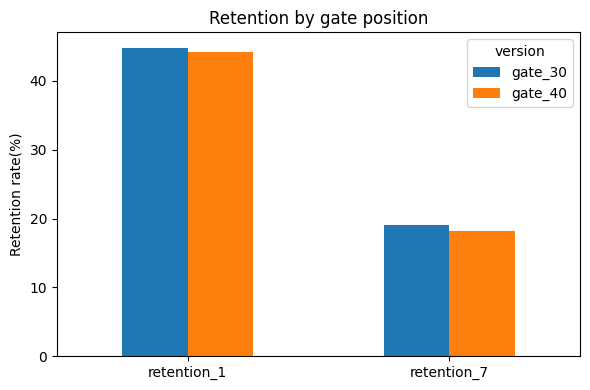

In [10]:
summary.T.plot(kind = "bar", figsize = (6, 4))
plt.ylabel("Retention rate(%)")
plt.title("Retention by gate position")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.savefig("retention_chart.png")
plt.show()

In [11]:
p1, p2 = 0.190, 0.182
effect = proportion_effectsize(p1, p2)
n = NormalIndPower().solve_power(effect_size = effect, alpha = 0.05,power = 0.8, ratio = 1)
print(f"Players needed per group: {int(n):,}")


Players needed per group: 37,132


## Conclusion

**Experiment:** Cookie Cats, a mobile puzzle game, tested moving the first progression gate from level 30 (control) to level 40 (test). Players were randomly assigned: 44,700 to gate_30 and 45,489 to gate_40.

**Method:** Two-proportion z-tests on 1-day and 7-day retention, with 95% confidence intervals for the difference. H0: retention is equal across versions. H1: it differs.

**Results:**

| Metric | gate_30 | gate_40 | p-value | 95% CI (gate_30 − gate_40) |
|---|---|---|---|---|
| 1-day retention | 44.82% | 44.23% | 0.0744 | [−0.06%, 1.24%] |
| 7-day retention | 19.02% | 18.20% | 0.0016 | [0.31%, 1.33%] |

- 1-day retention: no statistically significant difference at the 5% level.
- 7-day retention: gate_30 is significantly higher. Moving the gate to level 40 is associated with roughly 4% fewer players (0.82 pts of 19.02%) returning after a week.
- Power check: about 37,000 players per group were needed to detect a difference of this size with 80% power; both groups exceeded this.

**Recommendation:** Keep the gate at level 30. There is no evidence that level 40 helps retention, and there is evidence that it hurts 7-day retention.

**Limitations:**
- Only retention was analysed. Revenue, engagement depth and in-app purchases were not measured, and a later gate could affect monetisation.
- The effect is small in absolute terms (under 1 percentage point), though statistically reliable at this sample size.
- Two metrics were tested, which raises false-positive risk. The 7-day result remains significant after correction.
- Observational follow-up (e.g. revenue per user) would be needed before a final business decision.